# US equities panel: what a penalized linear map of the cross-section is worth

This is the first model fitted in the case study, and deliberately the simplest one that can use
the whole feature set: a linear map from the features observed at one close to the return over
the following days.

Fitting it first is not a formality. A linear model cannot represent an interaction between two
features, so whatever it achieves is what the features provide on their own. Every later model
here is more expressive and much more expensive, and what each one adds is only readable against
this number.

Two properties of this panel decide how the grid has to be read, and both differ from the
smaller case studies in the book.

**The cross-section is wide and the history is long.** Roughly three thousand names, sixteen
walk-forward splits, ten years of training window behind each one. That combination is why a
single configuration here costs minutes rather than seconds, and it is also why the estimates
are comparatively stable: an IC averaged over sixteen validation years and thousands of names
per day has far less sampling noise in it than the same quantity from a hundred-name universe
over two folds.

**The features are built from overlapping views of the same price and volume history** - several
momentum windows, several volatility windows, the same quantities at several lookbacks - so many
columns carry almost the same information. A design matrix like that is **collinear**, and many
different coefficient vectors fit the training window about equally well. Ordinary least squares
has no way to choose between them and will spend a large positive coefficient on one feature
against a large negative one on a near-copy. **Regularization** is the fix: penalize coefficient
size, so a solution that spreads weight across correlated features is preferred to one that
plays them off against each other. How much penalty is an empirical question, and the grid below
is the experiment that answers it.

**Learning objectives.** By the end of this notebook you will be able to:

- Read the set of models this case study declares for each label, and say which estimator and
  which hyperparameters each declared name resolves to.
- Bind those declarations to the data on disk and check, before anything is fitted, that every
  configuration will be measured on the same names, the same dates and the same folds.
- Explain why a panel this size is *planned* rather than resolved, and what that costs and saves.
- Fit a population of models on walk-forward folds and publish one complete set of validation
  predictions per configuration and label.
- Tell apart the two things a penalty can do to a collinear feature set - shrink correlated
  coefficients towards each other, or select a few and zero the rest - and read from the results
  which one this data rewards.
- Recognise when an information coefficient is an artifact of a model that scored fewer dates
  than its neighbours, and use coverage to rule it out.

**Docker image**: `ml4t`

**Book reference**: Chapter 11, Section 11.2 (Regularized Linear Models). Chapter 6, Section 6.7
(Search accounting and run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices, and
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds.

**What it writes**: one training run and one complete validation prediction set per
configuration and label, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`16_backtest`](16_backtest.ipynb) reads that population, runs every member against the
equal-weight baseline, and selects on validation backtest Sharpe. **Selection happens there, not
here.** This notebook ranks configurations by information coefficient to show what
regularization does to a collinear feature set; that ranking decides nothing.

In [1]:
"""Fit the declared US equities panel linear population on the walk-forward folds."""

import re

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.research import (
    candidate_set_supersedes,
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    plan_models,
    planned_model_plan,
    primary_label,
    run_model_population,
    supersedes_for_run,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
DIAGNOSTIC_CONFIG_NAMES = ["ols"]
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""

# A candidate set is sealed once written, so a run whose members differ from the recorded
# generation has to name the set it replaces, keyed by the full set name because that is what
# the refusal prints. These two moved when 04_model_based_features was rebuilt at production
# scale on 2026-09-10: every stage-06 training run registered before that pinned the superseded
# `model_based` artifact, so the whole catalog refitted and both 2026-08-18 generations went
# stale.
# Resolved through `candidate_set_supersedes` rather than passed straight to `freeze`, because a
# reader's clean clone has no generation to supersede and `create` refuses a first version that
# claims to replace one.
#
# The four `fwd_ret_5d` and `fwd_ret_21d` entries were added 2026-09-11, and the comment they
# replace - "have no recorded generation and need no entry" - was true when it was written and
# stopped being true when this notebook ran. The 2026-09-10 run created all six sets; the two
# `fwd_ret_1d` ones already had a generation to supersede and were the only two that needed
# declaring to get that run published. The other four are now gen 1 and live, so the NEXT run
# that moves their members is refused at the freeze, which is after the fit. That refusal cost
# 78 minutes of cold fitting once already.
#
# A literal here names the generation in force, and it is re-typed whenever that generation
# moves. The two arms of `candidate_set_supersedes` are not two equally good declarations:
# `create` matches on the member list before it reads the declaration at all, so naming the tip
# on an unchanged re-run writes nothing, while naming what the tip replaced raises
# "must explicitly supersedes <tip>" as soon as the members do move - at the freeze, after the
# fit. The tip is therefore correct on both the re-run and the refit and the predecessor is
# correct on only one of them, so there is no run on which the predecessor is the better
# declaration. Reproduced against `CandidateSet.create` and `OfficialPopulation.create` on
# 2026-09-11; the guard is `same_list` in research/population.py and the `bound is not None`
# branch in research/comparison.py.
SUPERSEDES_SETS: dict = {
    "us-equities-fwd-ret-1d-linear-v1": "55d64275dfd6",
    "us-equities-fwd-ret-1d-linear-diagnostics-v1": "ed1840bfaeb8",
    "us-equities-fwd-ret-5d-linear-v1": "e7b744f380d5",
    "us-equities-fwd-ret-5d-linear-diagnostics-v1": "5514968cd0bb",
    "us-equities-fwd-ret-21d-linear-v1": "6e8179623f0a",
    "us-equities-fwd-ret-21d-linear-diagnostics-v1": "636c1c2425aa",
}

In [3]:
study = open_study("us_equities_panel", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which labels, and which models

A label is the thing being predicted. This case study declares three in `config/setup.yaml`:
`fwd_ret_1d` is the primary one - the horizon the strategy chapters trade - and `fwd_ret_5d` and
`fwd_ret_21d` are the same construction over longer forward windows.

**`LABELS = []` fits all of them in one run**, which is what the empty list means: not "no
labels" but "every label whose training menu declares this family". Each label carries its own
menu at `config/training/{label}.yaml`, so the grid is read from the menus rather than from a
constant in this notebook that would have to be kept in step with them.

In [4]:
declared_labels(study, "linear")

('fwd_ret_1d', 'fwd_ret_21d', 'fwd_ret_5d')

Each name in a menu resolves to a preset in `case_studies/config/{model_type}/`, which holds
that configuration's hyperparameters. The frame below is the menu, with each name resolved to
the estimator class it names and the arguments that class is constructed with. To change what
runs, edit the menu or the presets rather than this notebook.

The grid covers the two shapes a penalty can take:

- **Ridge** penalizes the sum of squared coefficients. It shrinks correlated coefficients
  towards each other and keeps every feature, at a strength set by `alpha`. The grid steps
  `alpha` by powers of ten across ten orders of magnitude, because the useful value depends on
  the scale and the collinearity of the design matrix and neither is known in advance.
- **Lasso** penalizes the sum of absolute coefficients, which drives some of them exactly to
  zero: it selects features rather than shrinking them. **ElasticNet** mixes the two.

Lasso and ElasticNet are declared with a raw `alpha`, two values each an order of magnitude
apart, and ElasticNet also carries `l1_ratio` - the share of the penalty that is L1 rather than
L2. An L1 penalty behaves differently from Ridge in one way that matters for reading the grid:
for any fold there is a threshold penalty $\alpha_{\max}$, the smallest one that zeros every
coefficient, and where it falls depends on that fold's own design matrix. So one declared
`alpha` is a different fraction of the way to that threshold on every fold, and a configuration
can zero out on some folds and not on others. Section 4's coverage column is what shows it.

In [5]:
configs = load_model_configs(
    study,
    "linear",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""linear""","""fwd_ret_1d""","""ols""","""LinearRegression""","""defaults"""
"""linear""","""fwd_ret_1d""","""ridge_a0.001""","""Ridge""","""alpha=0.001"""
"""linear""","""fwd_ret_1d""","""ridge_a0.01""","""Ridge""","""alpha=0.01"""
"""linear""","""fwd_ret_1d""","""ridge_a0.1""","""Ridge""","""alpha=0.1"""
"""linear""","""fwd_ret_1d""","""ridge_a1.0""","""Ridge""","""alpha=1.0"""
…,…,…,…,…
"""linear""","""fwd_ret_5d""","""ridge_a10000000.0""","""Ridge""","""alpha=10000000.0"""
"""linear""","""fwd_ret_5d""","""lasso_a0.01""","""Lasso""","""alpha=0.01, max_iter=1000"""
"""linear""","""fwd_ret_5d""","""lasso_a0.1""","""Lasso""","""alpha=0.1, max_iter=1000"""


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
population from the canonical one. Publishing it under the canonical name would leave that name
meaning two different member sets at two different times, so the guard below requires a run that
narrows anything to say what to call its population.

In [6]:
if narrows_declared_catalog(study, "linear", configs) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the declared configurations, so it cannot publish "
        "the canonical population; pass POPULATION_NAME to give it its own"
    )

# Only an unnarrowed canonical run publishes the diagnostic set, so only that run has to carry
# every diagnostic configuration. A narrowed or preview run publishes no name and is free to
# leave any of them out.
is_published_population = (
    EXECUTION_TIER == "canonical" and not POPULATION_NAME and not PREVIEW_REDUCTIONS
)
if is_published_population:
    unknown_diagnostics = sorted(
        set(DIAGNOSTIC_CONFIG_NAMES) - set(configs.get_column("config_name").unique().to_list())
    )
    if not DIAGNOSTIC_CONFIG_NAMES or unknown_diagnostics:
        raise ValueError(
            "an unnarrowed canonical run publishes the diagnostic set, so its configurations "
            f"have to be among the ones fitted: {unknown_diagnostics}"
        )

## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which feature columns exist today,
where the walk-forward folds fall, or which symbol-date pairs carry both a feature row and a
label. **Planning** works all of that out - every training and prediction identity, derived from
the declarations and the fold boundaries in `config/setup.yaml` - without holding the data it was
derived from.

On this case study that distinction is the difference between a notebook that runs and one that
does not. A *resolved* request carries its prepared folds: the standardized design matrix for
every training window, for one configuration. Resolving the whole grid before fitting would hold
one copy per configuration of a panel with roughly three thousand names and sixteen ten-year
training windows. Planning prices the grid from the declarations and keeps nothing but the plan;
execution then walks folds on the outside and configurations on the inside, so one prepared fold
is live at a time however many configurations were declared.

The plan is the population, written down before anything is fitted. Three things to check in the
table below:

- **`feature_count` and `eligible_rows` agree within a label.** A row that differs is a
  configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits declared in
  `config/setup.yaml`.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.

`eligible_rows` differs *between* labels and should: a 21-day forward window runs out earlier
than a one-day window, so the longer horizon has fewer scorable dates to begin with.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
    notebook="06_linear",
)
plan = plan_models(study, requests=requests)

planned = planned_model_plan(plan)
planned.select(
    "label",
    "config_name",
    "task",
    "feature_count",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,task,feature_count,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,str,i64,i64,i64,i64,str,str
"""fwd_ret_1d""","""enet_a0.01""","""regression""",71,7170323,16,1,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
"""fwd_ret_1d""","""enet_a0.1""","""regression""",71,7170323,16,1,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
"""fwd_ret_1d""","""lasso_a0.01""","""regression""",71,7170323,16,1,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
"""fwd_ret_1d""","""lasso_a0.1""","""regression""",71,7170323,16,1,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
"""fwd_ret_1d""","""ols""","""regression""",71,7170323,16,1,"""1999-12-22 00:00:00""","""2015-12-30 00:00:00"""
…,…,…,…,…,…,…,…,…
"""fwd_ret_5d""","""ridge_a1000.0""","""regression""",71,7160171,16,1,"""1999-12-22 00:00:00""","""2015-12-23 00:00:00"""
"""fwd_ret_5d""","""ridge_a10000.0""","""regression""",71,7160171,16,1,"""1999-12-22 00:00:00""","""2015-12-23 00:00:00"""
"""fwd_ret_5d""","""ridge_a100000.0""","""regression""",71,7160171,16,1,"""1999-12-22 00:00:00""","""2015-12-23 00:00:00"""


`checkpoints` is 1 on every row, and that is the structural difference between this notebook and
[`07_gbm`](07_gbm.ipynb). A linear model has no intermediate states worth scoring: there is one
fit per configuration and fold, so one candidate per configuration. A boosted model has a
meaningful state at every iteration, which is why the next notebook has to count candidates
differently.

## 3. Fitting the population

`run_model_population` fits every planned request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on training rows only
   and then applied to the validation rows, so nothing from the validation window reaches the
   fit,
3. fits the estimator with that fold's resolved parameters,
4. predicts the fold's validation rows.

The fold predictions are concatenated into one series covering the whole validation period,
which is what a walk-forward prediction set is: each date predicted by a model that saw only
data before it. The run then writes a `training_runs` row and the fitted coefficients, a
`prediction_sets` row and the predictions themselves, and the metrics computed from them. It
does this per configuration rather than once at the end, so an interruption costs the
configuration in flight and nothing else - which on a panel where a single configuration is a
matter of minutes is the difference between losing one and losing a day.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
is going to produce. The list is computed before the first fit and written down, and afterwards
every member must exist and be complete. That is what makes the downstream comparison well
defined - `16_backtest` backtests this population, not whatever predictions happen to be in the
registry - and it is why a configuration that raises fails the whole call rather than publishing
a population one member short. Everything that finished stays registered, and re-running fits
only what is missing.

**One population covers all three labels**, because one run fits them all and the population is
what that run declares. A population is immutable once written, so a notebook that fitted one
label per run under a single name would publish the first label and be refused for the second.

`SUPERSEDES_POPULATION` names the population hash this run replaces. A population is a set of
prediction identities, so anything that moves a training identity - a changed estimator
parameter as much as a changed menu - produces a different population under the same name, and
the registry refuses to write it without being told which snapshot it supersedes. That lineage
is the only record of which generation is which.

A declared `SUPERSEDES_POPULATION` hash only means something where a generation of this name
already exists. A preview run, a first canonical run against an empty `run_log/`, and a run
under a caller-chosen `POPULATION_NAME` are all refused by `OfficialPopulation.create` if one
is passed anyway, so `supersedes_for_run` works out which of those cases this run is and
resolves the hash accordingly.

In [8]:
population_name = POPULATION_NAME or "us-equities-linear-checkpoints-v1"
supersedes = supersedes_for_run(
    study,
    population_name=population_name,
    declared=SUPERSEDES_POPULATION,
    execution_tier=EXECUTION_TIER,
)
execution, population = run_model_population(
    study,
    plan,
    population_name=population_name,
    supersedes=supersedes,
)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

48 configurations: 0 folds fitted, 768 reused
population us-equities-linear-checkpoints-v1: 48 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the registry
already holds the matching rows, and the runner returns the stored result rather than fitting
again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("us_equities_panel", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "linear", labels=["fwd_ret_1d"], config_names=["ridge_a100.0", "ridge_a1000.0"]
)
requests = model_requests(study, configs)
plan = plan_models(study, requests=requests)
execution, population = run_model_population(study, plan, population_name="my-linear-v1")
```

Narrow to a couple of configurations on one label before running anything wide here: at panel
scale a full grid is hours, and the point of a first pass is to find out that the plumbing works.

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not declare
raises rather than quietly fitting fewer models than you asked for. To fit something new, add a
preset at `case_studies/config/ridge/ridge_a3.0.yaml` and list `ridge_a3.0` under `linear:` in
the label's menu. Editing an existing preset changes that configuration's identity, so its
result registers as a new row beside the old one instead of replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What came out

One row per configuration and label, read back from the registry. `ic_mean` is the **information
coefficient**: on each validation date, rank the names by the model's prediction, rank them by
the return they went on to earn, correlate the two rankings, and average that daily correlation
over the validation period. It measures whether the model ranks names correctly, on a scale
where zero is no relationship.

Coverage is judged against **each label's own** maximum number of scorable validation dates,
because a longer forward window runs out earlier and one global maximum would mark a whole label
incomplete for a reason unrelated to any model. Within a label, `full_coverage` marks the
configurations measured on all of them.

What the count is for: a model whose coefficients collapse to one or two features predicts
nearly the same value for every name on some dates, and a constant has no rank correlation with
anything, so those dates contribute nothing. Its `ic_mean` is then an average over fewer dates
than its neighbours', chosen by where it happened to stay non-degenerate, and comparing it with
theirs compares two different samples.

In [9]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "complete",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort(["label", "ic_mean"], descending=[False, True])
    .join(
        configs.select("label", "config_name", "model_class", "params"),
        on=["label", "config_name"],
        how="left",
    )
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("linear execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
print(f"{catalog.height} candidate models across {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "model_class",
    "params",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
)

48 candidate models across 3 labels


label,config_name,model_class,params,ic_mean,ic_std,ic_n_days,full_coverage
str,str,str,str,f64,f64,f64,bool
"""fwd_ret_1d""","""ridge_a1000000.0""","""Ridge""","""alpha=1000000.0""",0.018286,0.009706,4031.0,true
"""fwd_ret_1d""","""ridge_a100000.0""","""Ridge""","""alpha=100000.0""",0.017667,0.010536,4031.0,true
"""fwd_ret_1d""","""ridge_a10000.0""","""Ridge""","""alpha=10000.0""",0.016109,0.010662,4031.0,true
"""fwd_ret_1d""","""ridge_a0.001""","""Ridge""","""alpha=0.001""",0.015987,0.010882,4031.0,true
"""fwd_ret_1d""","""ols""","""LinearRegression""","""defaults""",0.015987,0.010882,4031.0,true
…,…,…,…,…,…,…,…
"""fwd_ret_5d""","""ridge_a0.1""","""Ridge""","""alpha=0.1""",0.013589,0.01583,4027.0,true
"""fwd_ret_5d""","""lasso_a0.01""","""Lasso""","""alpha=0.01, max_iter=1000""",0.000786,0.007473,172.0,false
"""fwd_ret_5d""","""enet_a0.1""","""ElasticNet""","""alpha=0.1, l1_ratio=0.5, max_i…",0.000786,0.007473,172.0,false


## Freeze the compatible result sets

The population above is one immutable list covering every label this run fitted.
`16_backtest` never opens it: it opens *candidate sets*, named per `(label, family)`, because a
comparison is only meaningful within one label's protocol. `15_model_analysis` opens both - the
population, to confirm the run filled every member it promised, and the candidate sets, to make
the comparison. Freezing is what creates those names.

Without this the two downstream notebooks name six sets that nothing produces, and they fail
differently: `15` raises when `CandidateSet.one` cannot find the name, while `16` would simply
backtest whatever subset of names does resolve. A missing name is a silently narrower strategy
chain, which is the failure the named-set design exists to prevent.

The diagnostic subset is bounded hard, and the reason is arithmetic. `15` loads every diagnostic
member's raw prediction frame and holds them all while it joins them pairwise; one frame on this
panel is over seven million rows and about 225 MB in memory. So the set is one member per label and
family: the diagnostic configuration at its last checkpoint. Here that is `ols`, the unpenalized
baseline every penalized configuration is a shrinkage of, and a linear model has one fitted
state, so its last checkpoint is its only one.

Only an unnarrowed canonical run publishes. The guard on `narrows_declared_catalog` above already
refuses to publish the canonical *population* from a narrowed run; the same condition governs the
canonical set names, for the same reason - a name must not mean two different member sets.

In [10]:
set_rows = []
if is_published_population:
    for label_value in panel_labels:
        label_name = label_value.replace("_", "-")
        label_rows = execution.catalog_rows.filter(pl.col("label") == label_value)
        full_set_name = f"us-equities-{label_name}-linear-v1"
        full_set = study.predictions.freeze(
            label_rows,
            name=full_set_name,
            supersedes=candidate_set_supersedes(
                study, name=full_set_name, declared=SUPERSEDES_SETS.get(full_set_name, "")
            ),
        )
        diagnostic_rows = label_rows.filter(
            pl.col("config_name").is_in(DIAGNOSTIC_CONFIG_NAMES)
            # `.fill_null(True)` covers a family that publishes no checkpoint value at all, where
            # the comparison is null rather than false and would otherwise empty the frame.
            & (
                pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("config_name")
            ).fill_null(True)
        )
        if diagnostic_rows.height == 0:
            raise ValueError(
                f"no {label_value} rows for diagnostic configurations {DIAGNOSTIC_CONFIG_NAMES}"
            )
        diagnostic_set_name = f"us-equities-{label_name}-linear-diagnostics-v1"
        diagnostic_set = study.predictions.freeze(
            diagnostic_rows,
            name=diagnostic_set_name,
            supersedes=candidate_set_supersedes(
                study,
                name=diagnostic_set_name,
                declared=SUPERSEDES_SETS.get(diagnostic_set_name, ""),
            ),
        )
        set_rows.extend(
            [
                {
                    "role": "backtest population",
                    "set_name": full_set.name,
                    "members": len(full_set.members),
                },
                {
                    "role": "bounded diagnostics",
                    "set_name": diagnostic_set.name,
                    "members": len(diagnostic_set.members),
                },
            ]
        )
compatible_sets = pl.DataFrame(
    set_rows,
    schema={"role": pl.String, "set_name": pl.String, "members": pl.Int64},
)
compatible_sets

role,set_name,members
str,str,i64
"""backtest population""","""us-equities-fwd-ret-1d-linear-…",16
"""bounded diagnostics""","""us-equities-fwd-ret-1d-linear-…",1
"""backtest population""","""us-equities-fwd-ret-21d-linear…",16
"""bounded diagnostics""","""us-equities-fwd-ret-21d-linear…",1
"""backtest population""","""us-equities-fwd-ret-5d-linear-…",16
"""bounded diagnostics""","""us-equities-fwd-ret-5d-linear-…",1


### How the penalty grid ranks

Only the configurations measured on all of their label's scorable dates are charted. The
partial-coverage ones are in the table above with `full_coverage` false, and are left out here
because their IC is an average over a different set of dates.

The panels share a vertical scale so the horizons are compared rather than each one rescaled to
fill its own panel.

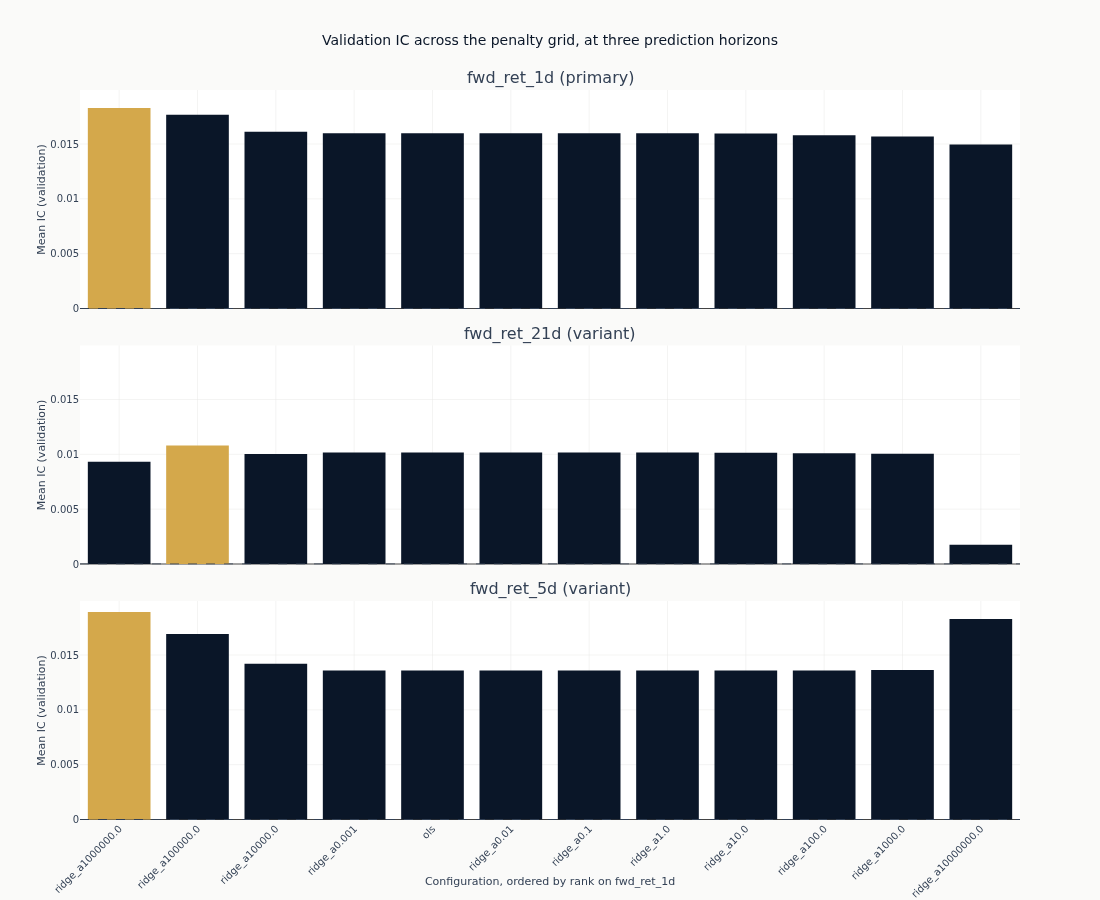

In [11]:
def compact(params: str) -> str:
    """Render declared parameters for a title: `alpha=1000000.0` reads as `alpha=1e+06`."""
    return re.sub(r"\d+\.?\d*(?:[eE][+-]?\d+)?", lambda m: f"{float(m.group()):g}", params)


full = catalog.filter("full_coverage")
config_order = (
    full.filter(pl.col("label") == panel_labels[0])
    .sort("ic_mean", descending=True)
    .get_column("config_name")
    .to_list()
)

# `shared_yaxes` matches axes across columns, so with one column it does nothing and each
# panel would be rescaled to fill itself. Matching every row to the first is what puts the
# horizons on one vertical scale, which is what stacking them is for.
fig_ic = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = full.filter(pl.col("label") == label)
    order = [name for name in config_order if name in set(panel.get_column("config_name"))]
    order += [name for name in panel.get_column("config_name").to_list() if name not in order]
    panel = panel.with_columns(
        rank=pl.col("config_name").replace_strict(
            {name: index for index, name in enumerate(order)}, return_dtype=pl.Int32
        )
    ).sort("rank")
    best = panel.get_column("ic_mean").max()
    fig_ic.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[
                COLORS["amber"] if value == best else COLORS["blue"]
                for value in panel.get_column("ic_mean")
            ],
            showlegend=False,
        ),
        row=row,
        col=1,
    )
    fig_ic.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_ic.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
    if row > 1:
        fig_ic.update_yaxes(matches="y", row=row, col=1)
fig_ic.update_xaxes(
    title_text=f"Configuration, ordered by rank on {panel_labels[0]}",
    tickangle=-45,
    row=len(panel_labels),
    col=1,
)
fig_ic.update_layout(
    title="Validation IC across the penalty grid, at three prediction horizons",
    height=300 * len(panel_labels),
    width=1100,
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig_ic,
    "Bar charts of mean validation information coefficient for every full-coverage linear "
    "configuration, one panel per declared label, sharing a vertical scale. Each panel's leading "
    "configuration is highlighted in amber and the rest are dark navy; the bars are held in the "
    "primary label's ranking order across every panel, so a panel that does not descend is a "
    "horizon that orders the grid differently. A dashed zero line runs across each panel.",
)

### What shrinkage does on its own

The bar chart mixes three estimators. Tracing IC across the Ridge penalty alone isolates the
effect of shrinkage, with the estimator, the features and the folds all held fixed and only
`alpha` moving. The alpha is read from each configuration's declared parameters rather than
parsed out of its name, so the curve plots what was fitted.

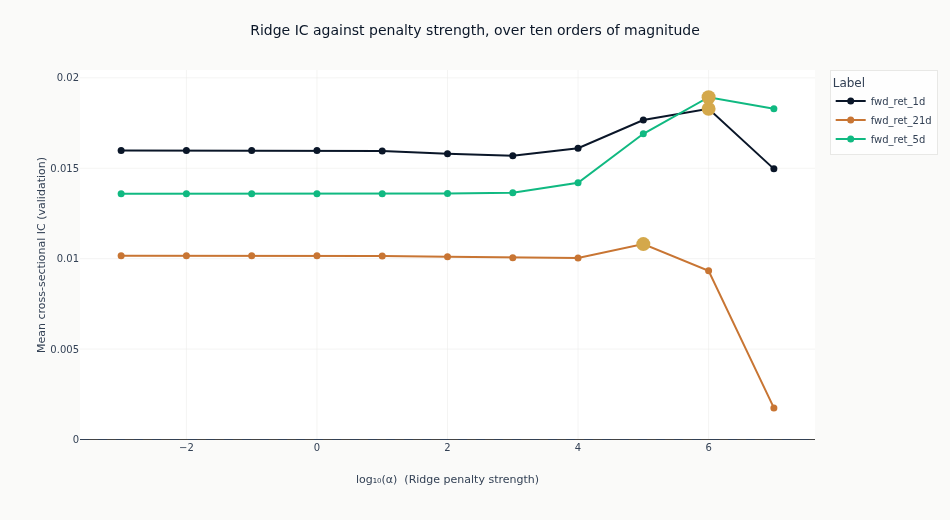

In [12]:
ridge = (
    catalog.filter(pl.col("model_class") == "Ridge")
    .with_columns(alpha=pl.col("params").str.extract(r"alpha=([0-9.eE+-]+)").cast(pl.Float64))
    .drop_nulls("alpha")
    .sort("label", "alpha")
)
if ridge.height:
    line_colors = [
        COLORS["blue"],
        COLORS["copper"],
        COLORS["positive"],
        COLORS["negative"],
        COLORS["slate"],
        COLORS["recede"],
    ]
    if len(panel_labels) > len(line_colors):
        raise ValueError(
            f"{len(panel_labels)} labels declared but only {len(line_colors)} distinct line "
            "colours; add colours rather than letting two labels share one"
        )
    fig_alpha = go.Figure()
    for index, label in enumerate(panel_labels):
        series = ridge.filter(pl.col("label") == label)
        if not series.height:
            continue
        log_alpha = np.log10(series.get_column("alpha").to_numpy())
        values = series.get_column("ic_mean").to_numpy()
        peak = int(np.argmax(values))
        # One colour per label, and amber is not among them: the peak marker is amber, so a
        # line drawn in it would swallow its own ring. Wrapping a short palette would give two
        # labels the same colour and two identical legend swatches.
        color = line_colors[index]
        fig_alpha.add_trace(
            go.Scatter(
                x=log_alpha,
                y=values,
                mode="lines+markers",
                name=label,
                line=dict(color=color, width=2),
                marker=dict(size=7, color=color),
            )
        )
        fig_alpha.add_trace(
            go.Scatter(
                x=[log_alpha[peak]],
                y=[values[peak]],
                mode="markers",
                marker=dict(size=14, color=COLORS["amber"]),
                showlegend=False,
            )
        )
    fig_alpha.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
    fig_alpha.update_layout(
        title="Ridge IC against penalty strength, over ten orders of magnitude",
        height=520,
        width=950,
        margin=dict(t=70),
        legend=dict(title_text="Label"),
    )
    fig_alpha.update_xaxes(title_text="log₁₀(α)  (Ridge penalty strength)", zeroline=False)
    fig_alpha.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    show_plotly_with_alt(
        fig_alpha,
        "Line chart of mean validation information coefficient against the base-ten logarithm of "
        "the Ridge penalty, one line per declared label over ten orders of magnitude, with each "
        "line's highest point marked in amber and a dashed zero line across the chart. A line "
        "that is flat at the left is a penalty too weak to bind; where it turns over is where "
        "shrinkage stops recovering signal and starts eroding it.",
    )
else:
    print(
        "No Ridge configurations were fitted, so there is no penalty sweep to trace. Which "
        "estimators this section can show is decided by the menus under config/training/."
    )

## 5. What to notice

**Where the Ridge curve turns tells you how collinear the design matrix is.** It is flat while
the penalty is too weak to bind, rises as shrinkage starts collapsing groups of near-duplicate
features onto their common direction, and falls once the penalty is strong enough to erode the
signal along with the noise. How far it climbs above its own flat left end is how much of the
signal collinearity was burying, because the left end is where the penalty is too weak to change
what the fit does. On a feature set close to orthogonal the curve would be nearly flat
throughout, and that comparison is worth making on your own data before spending a grid on it.

**Whether the three horizons agree is the second thing to read.** They are the same features and
the same folds, differing only in how far ahead the label looks. Where the orderings agree, the
grid is measuring something about the estimators; where they disagree, it is measuring something
about the horizon, and a penalty chosen on one horizon should not be carried to another on the
strength of that choice.

**Read the ranking with the coverage column or it will mislead you.** The most aggressive L1
settings can post a high raw IC while not being comparable to the rest: they zero all but a
couple of features on several folds, predict a near-constant value on those dates, and
contribute no correlation there. Read without `ic_n_days` such a table says hard feature
selection wins; read with it, the same table says those configurations failed on part of the
sample. The general lesson is that a metric averaged over a set the model itself selected is not
a metric.

**None of this selects anything.** IC measures whether predictions rank names correctly, not
whether a strategy trading them makes money after costs and turnover. Those are different
questions and a configuration can win the first while losing the second. Selection is on
validation backtest Sharpe over the population this notebook just published, and it happens in
[`16_backtest`](16_backtest.ipynb).

**Known limitations.** The IC here is an average of per-date rank correlations with no
adjustment for the serial dependence that overlapping forward returns create, so it is a ranking
diagnostic rather than a test. The grid is a one-dimensional sweep of penalty strength at fixed
features and fixed folds, so it says nothing about interactions between the penalty and either.
And every number here is measured on the validation folds, which have been read many times over
by the time a case study reaches this notebook.

**Next**: [`07_gbm`](07_gbm.ipynb) asks whether gradient boosting can find interactions in these
features that a linear map cannot represent at all.